# Named Entity Recognition(NER) — Sequence Labeling

## NER이란?
텍스트에서 **개체명(사람, 장소, 조직, 날짜 등)** 을 찾아 분류하는 작업

```
"삼성전자는 서울 강남구에 위치한 대기업이다."
  ───────    ──────────           
    ORG          LOC
```

## 시퀀스 레이블링 스키마 비교

### IOB2 태깅 스키마 (가장 일반적)

| 태그 | 의미 | 예시 |
|------|------|------|
| **B-XXX** | 개체 **시작** | B-PER (사람 시작) |
| **I-XXX** | 개체 **내부** | I-PER (사람 계속) |
| **O** | 개체 **아님** | O |

```
문장:   삼성   전자   는   서울   강남구   에   위치
IOB2: B-ORG I-ORG  O  B-LOC  I-LOC   O    O
```

### BIOES 스키마 (더 세밀)
```
B=Begin, I=Inside, O=Outside, E=End, S=Single

문장:   홍   길동   은   서울   에   삼성   전자   에   다닌다
BIOES: B-PER E-PER  O  S-LOC  O  B-ORG E-ORG  O    O
```

## 모델 아키텍처
```
입력 토큰
    ↓
Embedding(vocab, 64)
    ↓
BiLSTM(64→128, layers=2)
    ↓  ← 각 토큰마다 출력
Linear(256→num_tags)  ← 시퀀스 레이블링!
    ↓
[O, B-PER, I-PER, O, B-ORG, ...]  ← 토큰별 태그
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42); random.seed(42); np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')

✅ Device: cuda


## 1️⃣ IOB2 태깅 스키마 이해 — 직접 구성

In [2]:
# IOB2 태그 체계 직접 정의
ENTITY_TYPES = ['PER', 'LOC', 'ORG', 'DAT', 'NUM']  # 사람, 장소, 기관, 날짜, 숫자

# 태그 사전 생성
TAG2IDX = {'O': 0, 'PAD': 1}
for ent in ENTITY_TYPES:
    TAG2IDX[f'B-{ent}'] = len(TAG2IDX)
    TAG2IDX[f'I-{ent}'] = len(TAG2IDX)
IDX2TAG = {v: k for k, v in TAG2IDX.items()}

print('[IOB2 태그 사전]')
for tag, idx in TAG2IDX.items():
    print(f'  {idx:>2}: {tag}')

NUM_TAGS = len(TAG2IDX)
print(f'\n총 태그 수: {NUM_TAGS}')

[IOB2 태그 사전]
   0: O
   1: PAD
   2: B-PER
   3: I-PER
   4: B-LOC
   5: I-LOC
   6: B-ORG
   7: I-ORG
   8: B-DAT
   9: I-DAT
  10: B-NUM
  11: I-NUM

총 태그 수: 12


In [3]:
# IOB2 태깅 시각화
def visualize_iob2(sentence_tags: list[tuple[str, str]]):
    """(token, tag) 리스트를 시각적으로 출력"""
    tokens = [t for t, _ in sentence_tags]
    tags   = [t for _, t in sentence_tags]

    # 컬러 매핑
    color_map = {
        'PER': '\033[91m',  # 빨강
        'LOC': '\033[94m',  # 파랑
        'ORG': '\033[92m',  # 초록
        'DAT': '\033[93m',  # 노랑
        'NUM': '\033[95m',  # 보라
        'O':   '\033[0m',
    }
    RESET = '\033[0m'

    result = []
    for tok, tag in zip(tokens, tags):
        if tag == 'O':
            result.append(f'{tok}')
        else:
            ent_type = tag.split('-')[1]
            color = color_map.get(ent_type, '')
            result.append(f'{color}[{tok}/{tag}]{RESET}')

    print('  ' + ' '.join(result))
    print()


# 예시 문장 IOB2 태깅
examples_raw = [
    [('Samsung', 'B-ORG'), ('Electronics', 'I-ORG'), ('is', 'O'),
     ('located', 'O'), ('in', 'O'), ('Seoul', 'B-LOC'), ('.', 'O')],

    [('Steve', 'B-PER'), ('Jobs', 'I-PER'), ('founded', 'O'),
     ('Apple', 'B-ORG'), ('in', 'O'), ('1976', 'B-DAT'), ('.', 'O')],

    [('The', 'O'), ('meeting', 'O'), ('in', 'O'), ('New', 'B-LOC'),
     ('York', 'I-LOC'), ('was', 'O'), ('attended', 'O'), ('by', 'O'),
     ('100', 'B-NUM'), ('people', 'O'), ('.', 'O')],
]

print('[IOB2 태깅 시각화 예시]')
print('(색상: 빨강=PER, 파랑=LOC, 초록=ORG, 노랑=DAT, 보라=NUM)\n')
for ex in examples_raw:
    visualize_iob2(ex)

[IOB2 태깅 시각화 예시]
(색상: 빨강=PER, 파랑=LOC, 초록=ORG, 노랑=DAT, 보라=NUM)

  [Samsung/B-ORG] [Electronics/I-ORG] is located in [Seoul/B-LOC] .

  [Steve/B-PER] [Jobs/I-PER] founded [Apple/B-ORG] in [1976/B-DAT] .

  The meeting in [New/B-LOC] [York/I-LOC] was attended by [100/B-NUM] people .



## 2️⃣ CoNLL-2003 형식 데이터 준비

In [4]:
# CoNLL-2003 형식 샘플 데이터 (영문 NER)
# 형식: token \t tag (문장 구분은 빈 줄)

CONLL_SAMPLE = """
EU B-ORG
rejects O
German B-LOC
call O
to O
boycott O
British B-LOC
lamb O
. O

Peter B-PER
Blackburn I-PER
BRUSSELS B-LOC
1996-08-22 B-DAT

The O
European B-ORG
Commission I-ORG
said O
on O
Thursday O
it O
disagreed O
with O
Germany B-LOC
. O

Apple B-ORG
Inc I-ORG
was O
founded O
by O
Steve B-PER
Jobs I-PER
in O
California B-LOC
in O
1976 B-DAT
. O

Microsoft B-ORG
CEO O
Satya B-PER
Nadella I-PER
announced O
the O
deal O
in O
Seattle B-LOC
last O
Monday B-DAT
. O

Google B-ORG
opened O
a O
new O
office O
in O
New B-LOC
York I-LOC
City I-LOC
with O
500 B-NUM
employees O
. O

Barack B-PER
Obama I-PER
visited O
the O
United B-LOC
Nations I-LOC
headquarters O
in O
New B-LOC
York I-LOC
on O
September B-DAT
15 I-DAT
. O

Tesla B-ORG
reported O
record O
sales O
of O
2 B-NUM
million I-NUM
vehicles O
in O
2023 B-DAT
. O
""".strip()


def parse_conll(text: str) -> list[list[tuple]]:
    """CoNLL 형식 파싱 → [(token, tag), ...] 리스트의 리스트"""
    sentences, current = [], []
    for line in text.strip().split('\n'):
        line = line.strip()
        if not line:
            if current:
                sentences.append(current)
                current = []
        else:
            parts = line.split()
            if len(parts) >= 2:
                current.append((parts[0], parts[1]))
    if current:
        sentences.append(current)
    return sentences


sentences = parse_conll(CONLL_SAMPLE)
print(f'총 {len(sentences)}개 문장 파싱 완료')

# 태그 분포
all_tags = [tag for sent in sentences for _, tag in sent]
tag_dist = Counter(all_tags)
print(f'\n태그 분포:')
for tag, cnt in sorted(tag_dist.items(), key=lambda x: -x[1]):
    bar = '█' * cnt
    print(f'  {tag:>8}: {cnt:>3} | {bar}')

총 8개 문장 파싱 완료

태그 분포:
         O:  48 | ████████████████████████████████████████████████
     B-LOC:   9 | █████████
     B-ORG:   6 | ██████
     B-DAT:   5 | █████
     B-PER:   4 | ████
     I-PER:   4 | ████
     I-LOC:   4 | ████
     I-ORG:   2 | ██
     B-NUM:   2 | ██
     I-DAT:   1 | █
     I-NUM:   1 | █


## 3️⃣ 어휘 사전 & 데이터셋 구성

In [5]:
# 어휘 사전
all_tokens = [tok.lower() for sent in sentences for tok, _ in sent]
token_freq = Counter(all_tokens)

WORD2IDX = {'<PAD>': 0, '<UNK>': 1}
for word in token_freq:
    WORD2IDX[word] = len(WORD2IDX)
IDX2WORD = {v: k for k, v in WORD2IDX.items()}

print(f'어휘 크기: {len(WORD2IDX)}')
print(f'태그 수:   {NUM_TAGS}')


class NERDataset(Dataset):
    def __init__(self, sentences):
        self.data = []
        for sent in sentences:
            tokens = [WORD2IDX.get(tok.lower(), 1) for tok, _ in sent]
            tags   = [TAG2IDX.get(tag, TAG2IDX['O']) for _, tag in sent]
            self.data.append((
                torch.tensor(tokens, dtype=torch.long),
                torch.tensor(tags,   dtype=torch.long)
            ))

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]


def collate_ner(batch):
    """가변 길이 시퀀스 패딩"""
    tokens, tags = zip(*batch)
    tokens_pad = pad_sequence(tokens, batch_first=True, padding_value=0)
    tags_pad   = pad_sequence(tags,   batch_first=True, padding_value=TAG2IDX['PAD'])
    lengths    = torch.tensor([len(t) for t in tokens])
    return tokens_pad, tags_pad, lengths


# 데이터셋 분할 (작은 데이터이므로 전체로 train/eval)
# 실제 구현에서는 train/dev/test 분리
dataset = NERDataset(sentences)
split   = max(1, int(len(dataset) * 0.8))
train_ds = NERDataset(sentences[:split])
test_ds  = NERDataset(sentences[split:] if split < len(sentences) else sentences[-2:])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  collate_fn=collate_ner)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, collate_fn=collate_ner)

print(f'Train: {len(train_ds)}문장 / Test: {len(test_ds)}문장')

어휘 크기: 70
태그 수:   12
Train: 6문장 / Test: 2문장


## 4️⃣ BiLSTM NER 모델

### 시퀀스 레이블링 핵심
- 이미지/감성 분류: 전체 시퀀스 → **하나의 레이블**
- 시퀀스 레이블링:  각 토큰 → **각자의 레이블** ← 핵심 차이!

In [6]:
class BiLSTM_NER(nn.Module):
    """
    시퀀스 레이블링용 BiLSTM

    핵심: LSTM의 모든 시점 출력을 사용 (return_sequences=True)
    각 토큰 위치에서 태그 예측 → 출력 shape: (B, T, num_tags)
    """
    def __init__(self,
                 vocab_size  : int,
                 embed_dim   : int = 64,
                 hidden_dim  : int = 128,
                 num_layers  : int = 2,
                 num_tags    : int = NUM_TAGS,
                 dropout     : float = 0.3,
                 pad_idx     : int = 0):
        super().__init__()

        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_drop = nn.Dropout(dropout)

        self.bilstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # ★ 시퀀스 레이블링: 각 토큰마다 태그 예측
        self.fc      = nn.Linear(hidden_dim * 2, num_tags)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths=None):
        # x: (B, T)
        emb = self.embed_drop(self.embedding(x))  # (B, T, E)

        if lengths is not None:
            packed  = nn.utils.rnn.pack_padded_sequence(
                emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
            out_p, _ = self.bilstm(packed)
            out, _  = nn.utils.rnn.pad_packed_sequence(
                out_p, batch_first=True, total_length=x.size(1))
        else:
            out, _  = self.bilstm(emb)             # (B, T, 2H)

        logits = self.fc(self.dropout(out))        # (B, T, num_tags) ← 시퀀스 레이블링!
        return logits


model = BiLSTM_NER(
    vocab_size = len(WORD2IDX),
    embed_dim  = 64,
    hidden_dim = 128,
    num_layers = 2,
    num_tags   = NUM_TAGS,
    dropout    = 0.3,
).to(device)

print(f'파라미터: {sum(p.numel() for p in model.parameters()):,}')

# 출력 shape 확인
dummy = torch.randint(0, len(WORD2IDX), (2, 10)).to(device)
out   = model(dummy)
print(f'입력 shape: {tuple(dummy.shape)}')
print(f'출력 shape: {tuple(out.shape)}  → (배치, 시퀀스, 태그수)')
print(f'  ↑ 각 토큰마다 {NUM_TAGS}개 태그 확률 출력!')

파라미터: 601,484
입력 shape: (2, 10)
출력 shape: (2, 10, 12)  → (배치, 시퀀스, 태그수)
  ↑ 각 토큰마다 12개 태그 확률 출력!


## 5️⃣ 학습 함수 — 패딩 토큰 무시

In [7]:
# 패딩 위치 태그(PAD)는 손실 계산에서 제외
criterion = nn.CrossEntropyLoss(ignore_index=TAG2IDX['PAD'])
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for tokens, tags, lengths in loader:
        tokens, tags = tokens.to(device), tags.to(device)
        optimizer.zero_grad()

        logits = model(tokens, lengths)            # (B, T, num_tags)

        # (B*T, num_tags) vs (B*T,) 로 reshape
        loss = criterion(
            logits.view(-1, NUM_TAGS),
            tags.view(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # 토큰별 정확도 (PAD 제외)
        mask    = (tags != TAG2IDX['PAD'])
        preds   = logits.argmax(-1)
        correct += ((preds == tags) & mask).sum().item()
        total   += mask.sum().item()
        total_loss += loss.item()
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for tokens, tags, lengths in loader:
        tokens, tags = tokens.to(device), tags.to(device)
        logits = model(tokens, lengths)
        loss   = criterion(logits.view(-1, NUM_TAGS), tags.view(-1))

        mask   = (tags != TAG2IDX['PAD'])
        preds  = logits.argmax(-1)
        correct += ((preds == tags) & mask).sum().item()
        total   += mask.sum().item()
        total_loss += loss.item()

        # PAD 제외 태그 수집
        all_preds.extend(preds[mask].cpu().tolist())
        all_labels.extend(tags[mask].cpu().tolist())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# 학습
EPOCHS = 80
best_acc = 0.0
history  = {'tr_loss': [], 'tr_acc': [], 'te_acc': []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>9}")
print('=' * 45)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    _, te_acc, _, _ = evaluate(model, test_loader, criterion)
    scheduler.step()

    history['tr_loss'].append(tr_loss)
    history['tr_acc'].append(tr_acc)
    history['te_acc'].append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), '/tmp/best_ner.pt')

    if epoch % 20 == 0 or epoch == 1:
        print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {te_acc*100:>8.2f}%')

print(f'\n최고 Test Accuracy: {best_acc*100:.2f}%')

 Epoch | Train Loss | Train Acc |  Test Acc
     1 |     2.4748 |     9.84% |    52.00%
    20 |     1.0869 |    62.30% |    52.00%
    40 |     0.7914 |    73.77% |    48.00%
    60 |     0.7415 |    77.05% |    48.00%
    80 |     0.4797 |    86.89% |    44.00%

최고 Test Accuracy: 56.00%


## 6️⃣ 평가: Entity-level F1 (Span 기반)

In [8]:
def extract_entities(tokens: list, tags: list) -> list:
    """IOB2 태그 시퀀스에서 (시작, 끝, 타입) 스팬 추출"""
    entities = []
    current_entity = None
    for i, tag in enumerate(tags):
        if tag.startswith('B-'):
            if current_entity:
                entities.append(current_entity)
            current_entity = {'type': tag[2:], 'start': i, 'end': i, 'tokens': [tokens[i]]}
        elif tag.startswith('I-') and current_entity and tag[2:] == current_entity['type']:
            current_entity['end'] = i
            current_entity['tokens'].append(tokens[i])
        else:
            if current_entity:
                entities.append(current_entity)
            current_entity = None
    if current_entity:
        entities.append(current_entity)
    return entities


@torch.no_grad()
def predict_ner(sentence_tokens: list, model, verbose=True) -> list:
    model.eval()
    ids    = [WORD2IDX.get(tok.lower(), 1) for tok in sentence_tokens]
    x      = torch.tensor([ids], device=device)
    logits = model(x)                            # (1, T, num_tags)
    preds  = logits.argmax(-1)[0].cpu().tolist()
    tags   = [IDX2TAG[p] for p in preds]

    entities = extract_entities(sentence_tokens, tags)

    if verbose:
        pairs = list(zip(sentence_tokens, tags))
        print('  ' + ' '.join(f'{tok}/{tag}' for tok, tag in pairs))
        if entities:
            for ent in entities:
                text = ' '.join(ent['tokens'])
                print(f'  → [{ent["type"]}] "{text}" (위치: {ent["start"]}~{ent["end"]})')
        print()
    return entities


model.load_state_dict(torch.load('/tmp/best_ner.pt', map_location=device))

print('[NER 예측 테스트]\n')
test_sents = [
    ['Apple', 'CEO', 'Tim', 'Cook', 'spoke', 'in', 'California', '.'],
    ['Google', 'opened', 'new', 'offices', 'in', 'New', 'York', 'in', '2023', '.'],
    ['Barack', 'Obama', 'visited', 'the', 'United', 'Nations', '.'],
    ['Tesla', 'reported', '500', 'thousand', 'sales', 'last', 'quarter', '.'],
]
for sent in test_sents:
    print(f'문장: {" ".join(sent)}')
    predict_ner(sent, model, verbose=True)

[NER 예측 테스트]

문장: Apple CEO Tim Cook spoke in California .
  Apple/O CEO/O Tim/O Cook/O spoke/O in/O California/O ./O

문장: Google opened new offices in New York in 2023 .
  Google/O opened/O new/O offices/O in/O New/O York/O in/O 2023/O ./O

문장: Barack Obama visited the United Nations .
  Barack/O Obama/O visited/O the/O United/O Nations/O ./O

문장: Tesla reported 500 thousand sales last quarter .
  Tesla/O reported/O 500/O thousand/O sales/O last/O quarter/O ./O



## 7️⃣ 학습 곡선 & 태그 분포 시각화

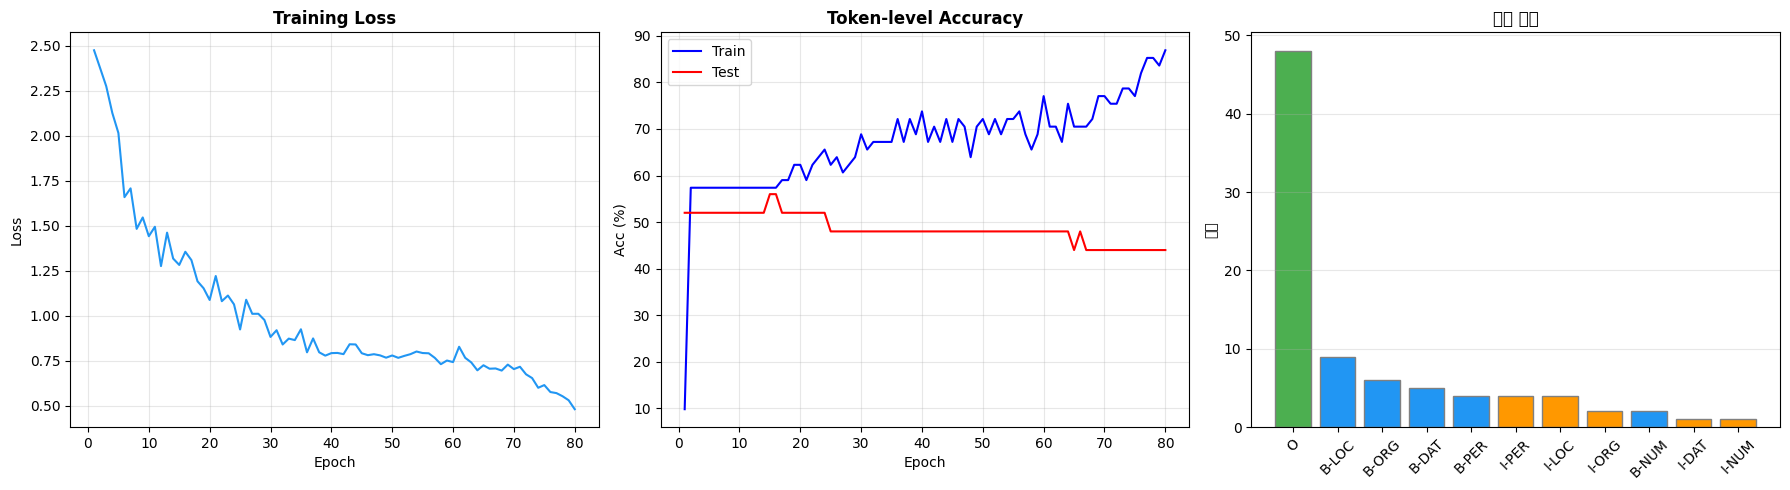

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep = range(1, EPOCHS + 1)
axes[0].plot(ep, history['tr_loss'], color='#2196F3')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['tr_acc']], 'b-', label='Train')
axes[1].plot(ep, [a*100 for a in history['te_acc']], 'r-', label='Test')
axes[1].set_title('Token-level Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 태그 분포
tags_sorted = sorted(tag_dist.items(), key=lambda x: -x[1])
tags_n, tags_c = zip(*tags_sorted)
colors_bar = ['#4CAF50' if t == 'O' else '#2196F3' if t.startswith('B') else '#FF9800' for t in tags_n]
axes[2].bar(tags_n, tags_c, color=colors_bar, edgecolor='gray')
axes[2].set_title('태그 분포', fontweight='bold')
axes[2].set_ylabel('빈도'); axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ner_sequence_labeling.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️⃣ IOB2 → BIOES 변환 (추가 실습)

In [11]:
def iob2_to_bioes(iob2_tags: list) -> list:
    """IOB2 태그 시퀀스를 BIOES로 변환"""
    bioes = []
    n = len(iob2_tags)
    for i, tag in enumerate(iob2_tags):
        if tag == 'O':
            bioes.append('O')
        elif tag.startswith('B-'):
            ent_type = tag[2:]
            # 다음 태그 확인
            next_tag = iob2_tags[i+1] if i+1 < n else 'O'
            if next_tag == f'I-{ent_type}':
                bioes.append(f'B-{ent_type}')  # 시작
            else:
                bioes.append(f'S-{ent_type}')  # 단일
        elif tag.startswith('I-'):
            ent_type = tag[2:]
            next_tag = iob2_tags[i+1] if i+1 < n else 'O'
            if next_tag == f'I-{ent_type}':
                bioes.append(f'I-{ent_type}')  # 내부
            else:
                bioes.append(f'E-{ent_type}')  # 끝
    return bioes


print('[IOB2 → BIOES 변환 예시]\n')
test_iob2_sents = [
    ['Steve', 'Jobs', 'founded', 'Apple', 'in', 'California'],
    ['EU', 'rejects', 'German', 'call'],
    ['New', 'York', 'City', 'is', 'big'],
]
test_iob2_tags = [
    ['B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC'],
    ['B-ORG', 'O', 'B-LOC', 'O'],
    ['B-LOC', 'I-LOC', 'I-LOC', 'O', 'O'],
]

for tokens, iob2 in zip(test_iob2_sents, test_iob2_tags):
    bioes = iob2_to_bioes(iob2)
    print(f'  문장:  {" ".join(tokens)}')
    print(f'  IOB2:  {iob2}')
    print(f'  BIOES: {bioes}')
    print()

[IOB2 → BIOES 변환 예시]

  문장:  Steve Jobs founded Apple in California
  IOB2:  ['B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC']
  BIOES: ['B-PER', 'E-PER', 'O', 'S-ORG', 'O', 'S-LOC']

  문장:  EU rejects German call
  IOB2:  ['B-ORG', 'O', 'B-LOC', 'O']
  BIOES: ['S-ORG', 'O', 'S-LOC', 'O']

  문장:  New York City is big
  IOB2:  ['B-LOC', 'I-LOC', 'I-LOC', 'O', 'O']
  BIOES: ['B-LOC', 'I-LOC', 'E-LOC', 'O', 'O']

